# Checkpoint quality and the learning clock
## Summary
The sealed primary record contains a real one-hour simulator training clock. This notebook queries exact saved checkpoint times and separates fixed-policy evaluation from changing-policy training diagnostics. No new model evaluation occurs here.

In [1]:
import hashlib
import html
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import HTML, Markdown, display

PROJECT = next(
    path for path in [Path.cwd(), *Path.cwd().parents] if (path / "src/gradientclimb").is_dir()
)
ROOT = PROJECT / "artifacts"
sys.path.insert(0, str(PROJECT / "src"))
sys.path.insert(0, str(PROJECT / "scripts"))
from gradientclimb.evaluation import compare_paired
from gradientclimb.experiments import connect_database, load_run, verify_run

PRIMARY = "c0a9e142-1ad6-4d88-810d-bda4ca297f40"
CHECKPOINT_EVALUATION = "b8df5a43-deb0-4b3a-917b-2398322c327c"
GENERALIZATION_EVALUATION = "3a9a0c20-e544-4efd-9c68-e2830d8e8224"
plt.rcParams.update(
    {
        "figure.figsize": (9, 4.5),
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.axisbelow": True,
    }
)
COLORS = {"source": "#087f8c", "shift": "#bc5a36", "reference": "#596b75"}


def show_table(headers, rows):
    heading = "".join(
        '<th style="text-align:left;padding:7px">' + html.escape(str(x)) + "</th>" for x in headers
    )
    body = "".join(
        "<tr>"
        + "".join(
            '<td style="padding:7px;border-top:1px solid #ddd;overflow-wrap:anywhere">'
            + html.escape(str(x))
            + "</td>"
            for x in row
        )
        + "</tr>"
        for row in rows
    )
    display(
        HTML(
            '<div style="overflow:auto"><table style="border-collapse:collapse;font-size:13px"><thead><tr>'
            + heading
            + "</tr></thead><tbody>"
            + body
            + "</tbody></table></div>"
        )
    )


primary = load_run(ROOT, PRIMARY)
assert primary["status"] == "completed"
assert verify_run(ROOT, PRIMARY)["valid"]
display(
    Markdown(
        f"**Primary source:** `{PRIMARY}`. Actual training: **{primary['summary']['training_clock_seconds']:.3f} s**; final validation mean **{primary['summary']['mean_distance']:.2f} nominal m**. Real-game qualification remains incomplete."
    )
)

**Primary source:** `c0a9e142-1ad6-4d88-810d-bda4ca297f40`. Actual training: **3600.322 s**; final validation mean **681.55 nominal m**. Real-game qualification remains incomplete.

## Context & methods
All distances are nominal units in the uncalibrated surrogate. The six checkpoints share validation seeds 10000–10019; they are correlated policies from one training seed, not six independent training replicates. Bootstrap intervals condition on the fixed policies and sampled evaluation episodes.
### Key assumptions
Canonical seals establish file integrity, not real-game fidelity. Imports, provenance and offline evaluation lie outside the recorded monotonic training clock. A final score never substitutes for an earlier time point.
## Data
### 1. Verify the exact source records

In [2]:
evaluation = load_run(ROOT, CHECKPOINT_EVALUATION)
assert evaluation["parent_run"] == PRIMARY and verify_run(ROOT, CHECKPOINT_EVALUATION)["valid"]
source_ids = [PRIMARY, CHECKPOINT_EVALUATION]
show_table(
    ["Run", "run.json SHA-256", "Status"],
    [
        [
            run_id,
            hashlib.sha256((ROOT / "runs" / run_id / "run.json").read_bytes()).hexdigest(),
            load_run(ROOT, run_id)["status"],
        ]
        for run_id in source_ids
    ],
)

Run,run.json SHA-256,Status
c0a9e142-1ad6-4d88-810d-bda4ca297f40,40084f1df3650db0285f7c0d63d4458cf4391263964e3a49bcabb2c43a1716c1,completed
b8df5a43-deb0-4b3a-917b-2398322c327c,25330554431b62e49840d00e3bf04cca7814bd7fe84406e9b35b2e0b77f7d3aa,completed


### 2. Query the recorded training curve
This parameterized DuckDB query uses the public canonical-store API. It reads a snapshot without locking the active reproduction writer.

In [3]:
sql = """
SELECT CAST(json_extract_string(dimensions_json, '$.training_elapsed_seconds') AS DOUBLE) AS training_seconds,
       value AS rolling_training_distance
FROM metrics
WHERE run_id = ? AND name = 'mean_episode_distance'
ORDER BY training_seconds
"""
with connect_database(ROOT) as connection:
    connection.execute("SET threads = 1")
    training_curve = connection.execute(sql, [PRIMARY]).fetchall()
assert training_curve and all(row[0] is not None for row in training_curve)
print(
    f"{len(training_curve)} recorded diagnostic points; first/last actual seconds: {training_curve[0][0]:.3f}, {training_curve[-1][0]:.3f}"
)

638 recorded diagnostic points; first/last actual seconds: 12.209, 3600.167


## Results
### 3. Inspect exact checkpoint values

In [4]:
checkpoint_rows = sorted(
    evaluation["evaluation_results"], key=lambda row: row["metadata"]["requested_minutes"]
)
registered_hashes = {
    row["sha256"] for row in primary["artifact_manifest"] if row["kind"] == "checkpoint"
}
for row in checkpoint_rows:
    assert row["checkpoint_hash"] in registered_hashes
    assert row["results"]["seeds"] == list(range(10000, 10020))
    recorded = row["results"]["summary"]["distance"]["mean"]
    assert (
        abs(
            sum(item["distance"] for item in row["results"]["episodes"])
            / len(row["results"]["episodes"])
            - recorded
        )
        < 1e-7
    )
show_table(
    ["Requested min", "Actual training s", "Mean m", "Median m", "Mean episode CI95%"],
    [
        [
            row["metadata"]["requested_minutes"],
            f"{row['metadata']['training_elapsed_seconds']:.3f}",
            f"{row['results']['mean_distance']:.2f}",
            f"{row['results']['median_distance']:.2f}",
            f"[{row['results']['summary']['distance']['ci95_low']:.2f}, {row['results']['summary']['distance']['ci95_high']:.2f}]",
        ]
        for row in checkpoint_rows
    ],
)

Requested min,Actual training s,Mean m,Median m,Mean episode CI95%
5.0,300.060,654.78,670.61,"[614.32, 694.04]"
10.0,601.031,676.58,678.06,"[640.60, 712.19]"
20.0,1200.218,691.37,705.24,"[651.33, 730.15]"
30.0,1801.191,657.34,709.48,"[573.66, 726.99]"
45.0,2701.384,683.84,705.67,"[641.50, 725.59]"
60.0,3600.002,681.55,716.12,"[621.36, 732.74]"


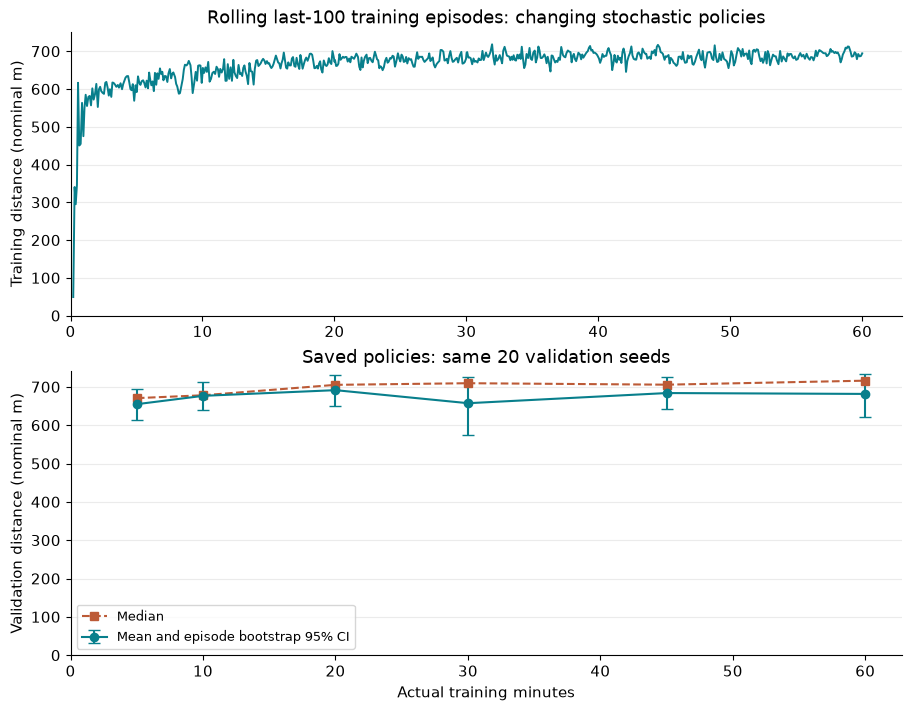

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7), layout="constrained")
axes[0].plot(
    [r[0] / 60 for r in training_curve],
    [r[1] for r in training_curve],
    color=COLORS["source"],
    linewidth=1.4,
)
axes[0].set(
    title="Rolling last-100 training episodes: changing stochastic policies",
    ylabel="Training distance (nominal m)",
)
times = [r["metadata"]["training_elapsed_seconds"] / 60 for r in checkpoint_rows]
means = [r["results"]["mean_distance"] for r in checkpoint_rows]
low = [m - r["results"]["summary"]["distance"]["ci95_low"] for m, r in zip(means, checkpoint_rows)]
high = [
    r["results"]["summary"]["distance"]["ci95_high"] - m for m, r in zip(means, checkpoint_rows)
]
axes[1].errorbar(
    times,
    means,
    yerr=[low, high],
    fmt="o-",
    color=COLORS["source"],
    capsize=4,
    label="Mean and episode bootstrap 95% CI",
)
axes[1].plot(
    times,
    [r["results"]["median_distance"] for r in checkpoint_rows],
    "s--",
    color=COLORS["shift"],
    label="Median",
)
axes[1].set(
    title="Saved policies: same 20 validation seeds",
    xlabel="Actual training minutes",
    ylabel="Validation distance (nominal m)",
)
for axis in axes:
    axis.set_xlim(left=0)
    axis.set_ylim(bottom=0)
    axis.grid(axis="y", alpha=0.25)
axes[1].legend(fontsize=9)
plt.show()

### 4. Compare the final policy with earlier policies
Differences are paired by episode seed. The displayed intervals do not account for training-seed variability or multiple exploratory comparisons.

In [6]:
final = next(row for row in checkpoint_rows if row["metadata"]["requested_minutes"] == 60)
paired = [
    (
        row["metadata"]["requested_minutes"],
        compare_paired(final["results"], row["results"])["distance_difference"],
    )
    for row in checkpoint_rows
    if row is not final
]
show_table(
    ["Earlier requested min", "Final minus earlier mean m", "Paired episode CI95%"],
    [
        [minute, f"{value['mean']:+.2f}", f"[{value['ci95_low']:.2f}, {value['ci95_high']:.2f}]"]
        for minute, value in paired
    ],
)

Earlier requested min,Final minus earlier mean m,Paired episode CI95%
5.0,+26.77,"[-0.39, 45.22]"
10.0,+4.98,"[-41.04, 31.70]"
20.0,-9.82,"[-56.55, 18.81]"
30.0,+24.21,"[-40.32, 89.88]"
45.0,-2.29,"[-28.43, 13.68]"


## Takeaways

In [7]:
increases = sum(
    checkpoint_rows[index]["results"]["mean_distance"]
    > checkpoint_rows[index - 1]["results"]["mean_distance"]
    for index in range(1, len(checkpoint_rows))
)
intervals_cross_zero = sum(value["ci95_low"] <= 0 <= value["ci95_high"] for _, value in paired)
display(
    Markdown(
        f"Observed mean increased at **{increases}/{len(checkpoint_rows) - 1}** successive saved checkpoints. **{intervals_cross_zero}/{len(paired)}** final-versus-earlier paired intervals include zero. Treat the curve as measured evidence from one training seed; the separately recorded seed43 reproduction is required to assess reproducibility. No simulator result here establishes real-game control."
    )
)

Observed mean increased at **3/5** successive saved checkpoints. **5/5** final-versus-earlier paired intervals include zero. Treat the curve as measured evidence from one training seed; the separately recorded seed43 reproduction is required to assess reproducibility. No simulator result here establishes real-game control.